In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import math
from warnings import filterwarnings
filterwarnings("ignore")
%matplotlib inline

In [17]:
df = pd.read_csv(r"D:\Data\Data_Entry_2017.csv")
df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN
5,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168,NaN
6,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168,NaN
7,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN
8,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168,NaN
9,00000003_005.png,Hernia,5,3,78,F,PA,2686,2991,0.143,0.143,NaN


In [18]:
df.tail(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
112110,00030797_000.png,No Finding,0,30797,24,M,PA,2021,2021,0.194311,0.194311,NaN
112111,00030798_000.png,No Finding,0,30798,30,M,PA,2500,2048,0.171000,0.171000,NaN
112112,00030799_000.png,No Finding,0,30799,32,M,PA,2048,2500,0.171000,0.171000,NaN
112113,00030800_000.png,No Finding,0,30800,34,F,PA,2048,2500,0.168000,0.168000,NaN
112114,00030801_000.png,No Finding,0,30801,39,M,PA,2500,2048,0.168000,0.168000,NaN
112115,00030801_001.png,Mass|Pneumonia,1,30801,39,M,PA,2048,2500,0.168000,0.168000,NaN
112116,00030802_000.png,No Finding,0,30802,29,M,PA,2048,2500,0.168000,0.168000,NaN
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168000,0.168000,NaN
112118,00030804_000.png,No Finding,0,30804,30,F,PA,2048,2500,0.168000,0.168000,NaN
112119,00030805_000.png,No Finding,0,30805,27,M,PA,2048,2500,0.171000,0.171000,NaN


In [19]:
df.shape

(112120, 12)

In [20]:
df.isna().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  str    
 1   Finding Labels               112120 non-null  str    
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  str    
 6   View Position                112120 non-null  str    
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), str(4)
memory usage: 13.7 MB


In [30]:
df["Image Index"].is_unique

True

In [31]:
all_labels = df['Finding Labels'].str.split("|").explode()
all_labels

0         Cardiomegaly
1         Cardiomegaly
1            Emphysema
2         Cardiomegaly
2             Effusion
              ...     
112115       Pneumonia
112116      No Finding
112117      No Finding
112118      No Finding
112119      No Finding
Name: Finding Labels, Length: 141537, dtype: str

In [32]:
label_counts = all_labels.value_counts()
label_counts

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64

In [33]:
df["Follow-up #"].value_counts()[0:15] # How many times person Join and followed up

Follow-up #
0     30805
1     13302
2      9189
3      7089
4      5759
5      4821
6      4034
7      3426
8      2932
9      2545
10     2225
11     1944
12     1709
13     1544
14     1363
Name: count, dtype: int64

In [34]:
df["Follow-up #"].value_counts()[:-15:-1] # How many times person Join

Follow-up #
183    1
182    1
181    1
180    1
179    1
178    1
177    1
176    1
175    1
174    1
173    1
172    2
171    2
170    2
Name: count, dtype: int64

In [35]:
len(df[df["Follow-up #"] == 0]["Patient ID"]) # How many person Join in first time

30805

In [36]:
len(df[df["Follow-up #"] == 1]["Patient ID"]) # How many person Joined who only still following up

13302

In [37]:
len(df[df["Follow-up #"] == 0]["Patient ID"]) - len(df[df["Follow-up #"] == 1]["Patient ID"]) # the result is mean to only 17503 person who only join in first time and not followed up anymore

17503

In [72]:
df["View Position"].value_counts()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

In [ ]:
df["Patient Gender"].value_counts()

Patient Gender
M    63340
F    48780
Name: count, dtype: int64

In [38]:
df['Patient Age'].describe()

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64

In [39]:
def set_age_group(x):
    x = int(x)
    if x <= 12:
        return "children"
    elif x <= 22:
        return "teenager"
    elif x <= 35:
        return "young adult"
    elif x <= 60:
        return "adult"
    else:
        return "elderly"

In [43]:
mixed_group = df[df["Follow-up #"] == 0][df["Patient Age"] < 120]["Patient Age"].apply(lambda x : set_age_group(x)) # See The Age Group in first time he joined
healthy_group = df[df["Follow-up #"] == 0][df["Patient Age"] < 120][df["Finding Labels"] == "No Finding"]["Patient Age"].apply(lambda x : set_age_group(x)) # See The Age Group for no finding in first time he joined
disease_group = df[df["Follow-up #"] == 0][df["Patient Age"] < 120][df["Finding Labels"] != "No Finding"]["Patient Age"].apply(lambda x : set_age_group(x)) # See The Age Group for disease found in first time he joined

In [44]:
mixed_group.value_counts()

Patient Age
adult          16001
elderly         6323
young adult     5625
teenager        1982
children         866
Name: count, dtype: int64

In [45]:
healthy_group.value_counts()

Patient Age
adult          11022
young adult     4337
elderly         3656
teenager        1523
children         653
Name: count, dtype: int64

In [46]:
disease_group.value_counts()

Patient Age
adult          4979
elderly        2667
young adult    1288
teenager        459
children        213
Name: count, dtype: int64

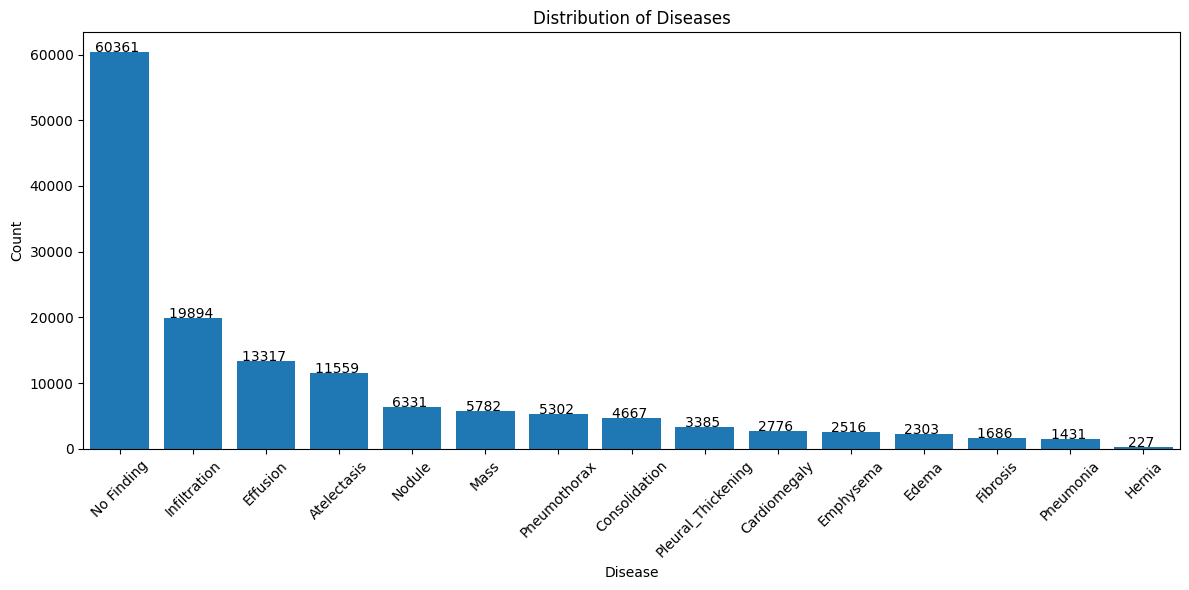

In [77]:
_, ax = plt.subplots(figsize=(8,5))
label_counts.plot(kind='bar', figsize=(12,6))

bars = ax.bar(label_counts.index, label_counts.values)

for i in range(len(bars)):
    ax.text(
        i,
        label_counts.values[i] + 1,
        f"{label_counts.values[i]} ",
        ha='center'
    )

plt.title('Distribution of Diseases')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
def Show_Counts(cols, df=None, titles=None):
    """
    cols: list of column names OR list of Series
    df: dataframe ( Optional  )
    titles: list of titles ( Optional )
    """

    n = len(cols)
    n_cols = 3  
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  

    for i, col in enumerate(cols):
        ax = axes[i]

        try:
            col_counts = df[col].value_counts()
            colname = col
        except:
            col_counts = col.value_counts()
            colname = col_counts.index.name if col_counts.index.name else f"Column {i+1}"

        bars = ax.bar(col_counts.index.astype(str), col_counts.values)

        
        for j, v in enumerate(col_counts.values):
            ax.text(j, v + 0.5, str(v), ha='center', fontsize=9)

        
        if titles:
            ax.set_title(titles[i])
        else:
            ax.set_title(colname)

        ax.set_xlabel("")
        ax.set_ylabel("Count")

    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

In [79]:
def FilterByFollowUp_Age(n):
    all_filters_data = []
    all_filters_titles = []
    
    for i in range(n):
        mixed_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120]["Patient Age"].apply(lambda x : set_age_group(x))
        healthy_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120][df["Finding Labels"] == "No Finding"]["Patient Age"].apply(lambda x : set_age_group(x)) 
        disease_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120][df["Finding Labels"] != "No Finding"]["Patient Age"].apply(lambda x : set_age_group(x)) 
        all_filters_data.extend([mixed_group,healthy_group,disease_group])
        all_filters_titles.extend([f"Age Group (MIX) at {i}",f"Age Group (NO FINDING) at {i}",f"Age Group (DISEASE FOUND) at {i}"])

    return all_filters_data,all_filters_titles

In [80]:
def FilterByFollowUp_Gender(n):
    all_filters_data = []
    all_filters_titles = []
    
    for i in range(n):
        mixed_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120]["Patient Gender"].replace({"M":0,"F":1})
        healthy_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120][df["Finding Labels"] == "No Finding"]["Patient Gender"].replace({"M":0,"F":1})
        disease_group = df[df["Follow-up #"] == i][df["Patient Age"] < 120][df["Finding Labels"] != "No Finding"]["Patient Gender"].replace({"M":0,"F":1})
        all_filters_data.extend([mixed_group,healthy_group,disease_group])
        all_filters_titles.extend([f"Gender Group (MIX) at {i}",f"Gender Group (NO FINDING) at {i}",f"Gender Group (DISEASE FOUND) at {i}"])

    return all_filters_data,all_filters_titles

In [81]:
def FilterByFollowUp_View(n):
    all_filters_data = []
    all_filters_titles = []
    
    for i in range(n):
        mixed_group = df[df["Follow-up #"] == i]["View Position"].replace({"PA":0,"AP":1})
        healthy_group = df[df["Follow-up #"] == i][df["Finding Labels"] == "No Finding"]["View Position"].replace({"PA":0,"AP":1})
        disease_group = df[df["Follow-up #"] == i][df["Finding Labels"] != "No Finding"]["View Position"].replace({"PA":0,"AP":1})
        all_filters_data.extend([mixed_group,healthy_group,disease_group])
        all_filters_titles.extend([f"View Position (MIX)",f"View Position (NO FINDING Captured)",f"View Position (DISEASE Captured)"])

    return all_filters_data,all_filters_titles

In [82]:
all_data , all_titles = FilterByFollowUp_Age(3)

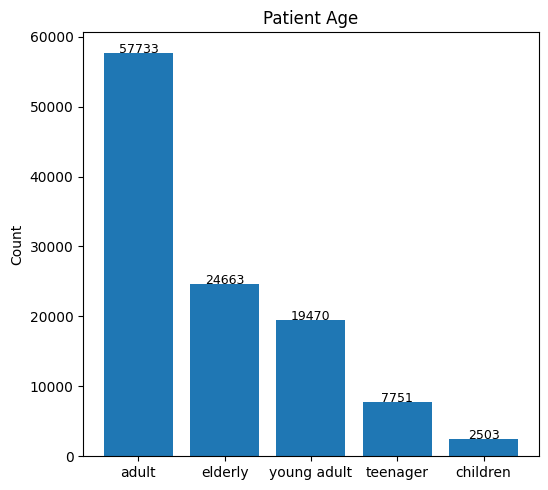

In [97]:
Show_Counts([df["Patient Age"].apply(lambda x: set_age_group(x))],df)

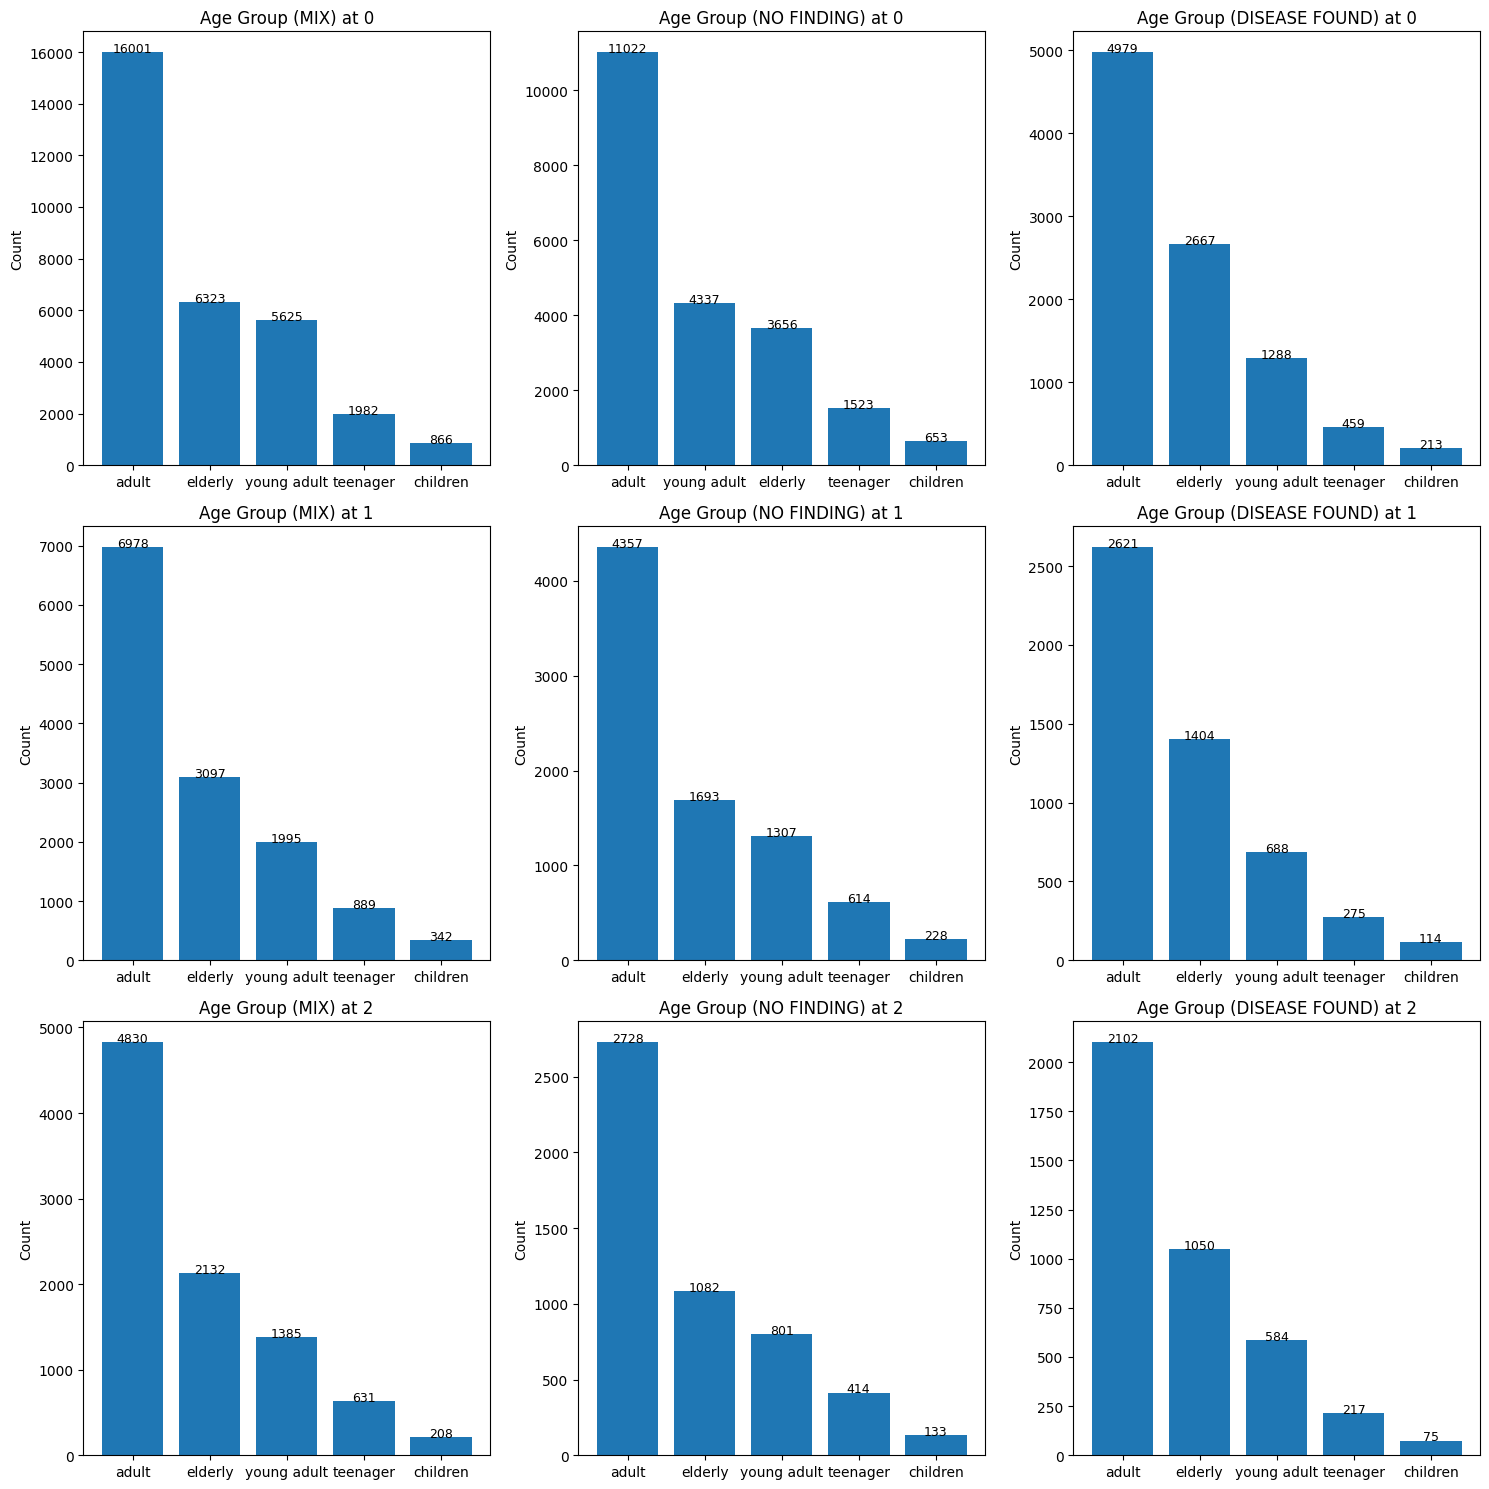

In [83]:
Show_Counts(all_data,df,all_titles)

In [84]:
all_data , all_titels = FilterByFollowUp_Gender(3)

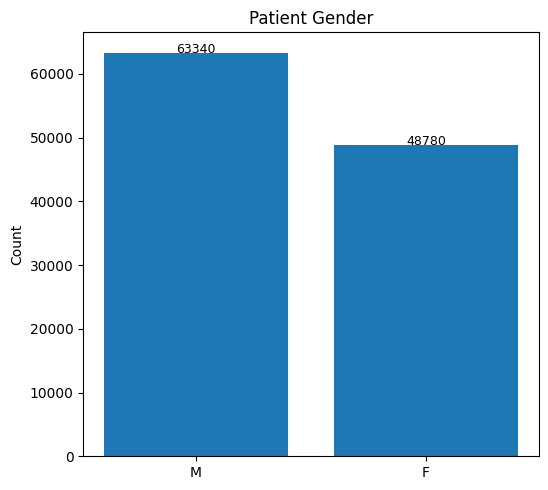

In [93]:
Show_Counts(["Patient Gender"],df)

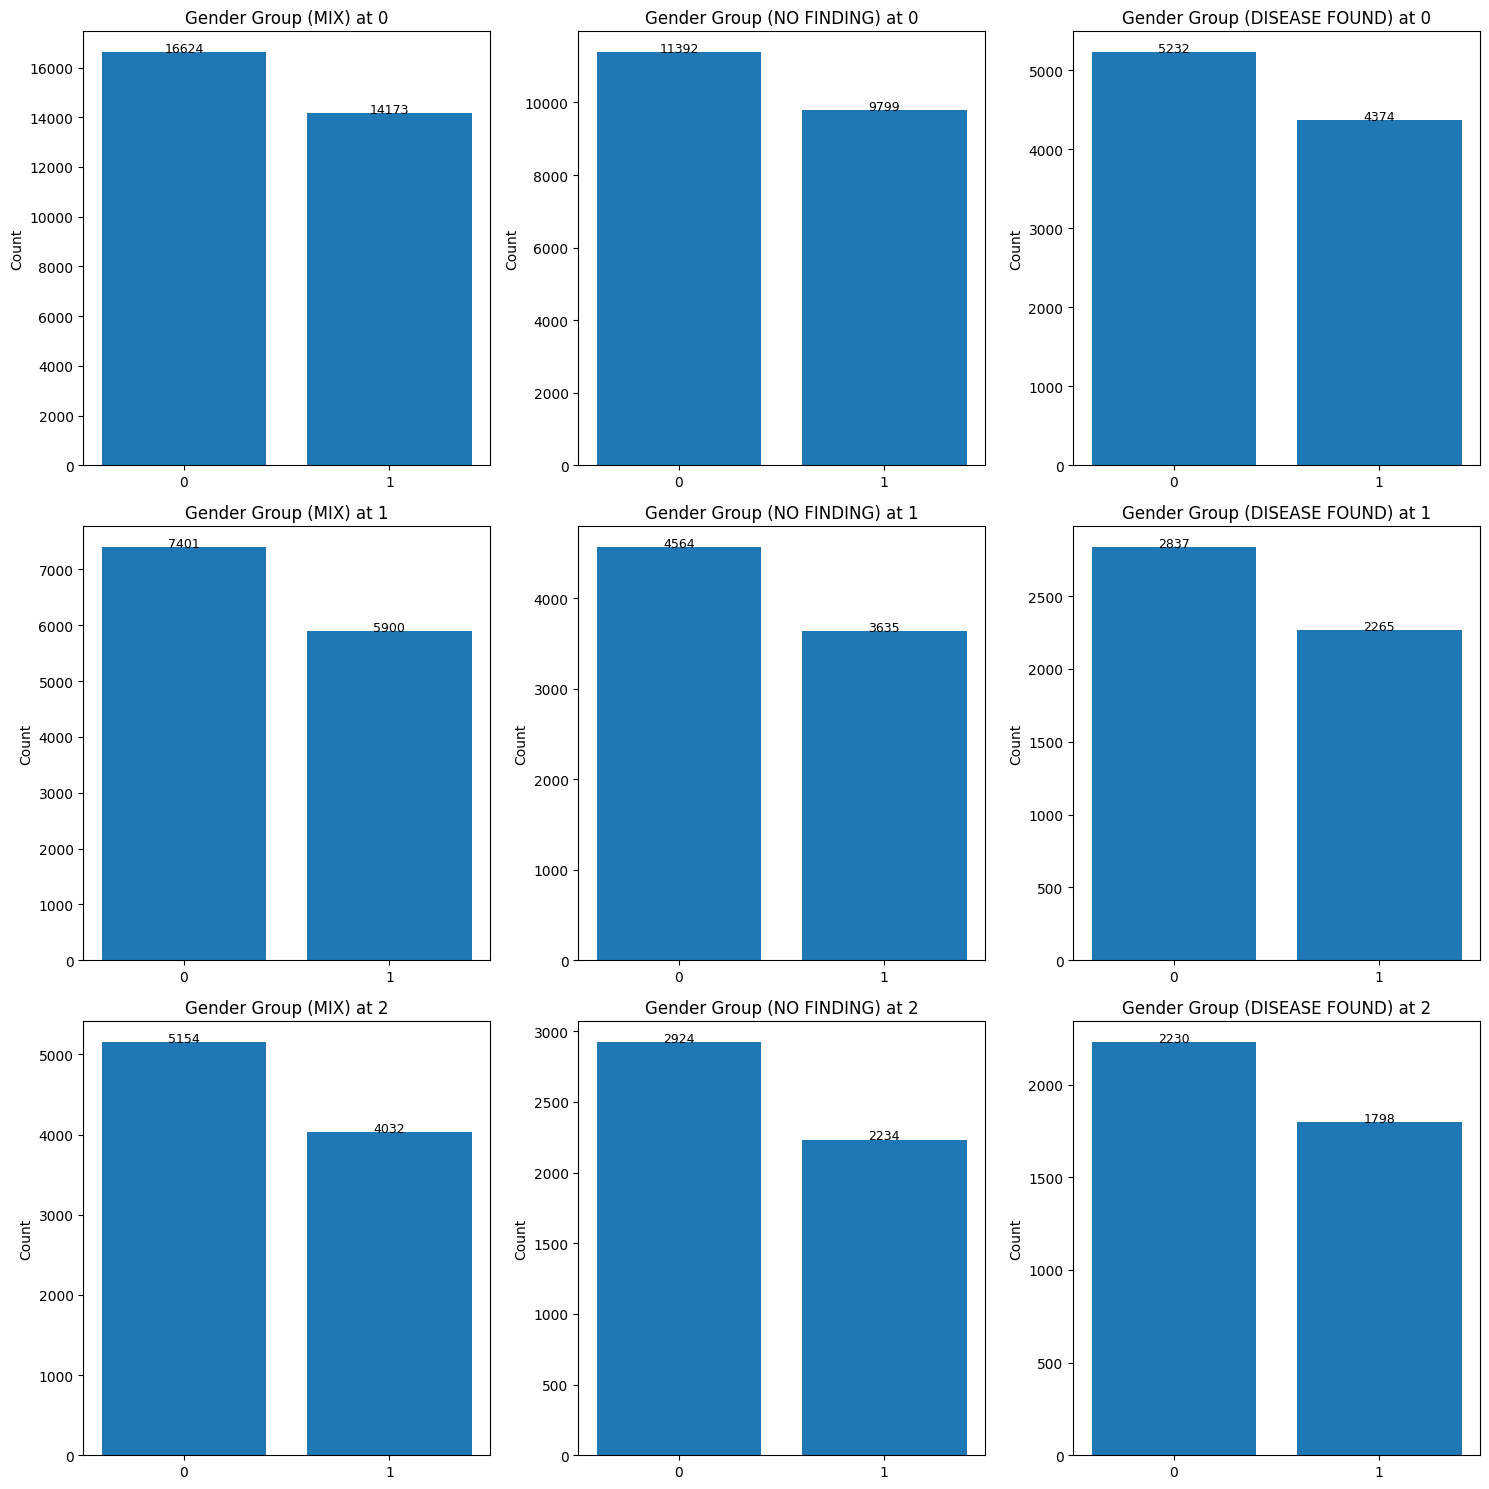

In [85]:
Show_Counts(all_data,df,all_titels)

In [87]:
all_data , all_titels = FilterByFollowUp_View(3)

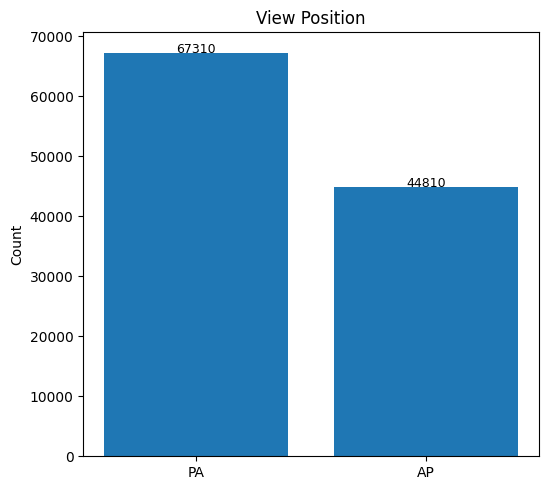

In [98]:
Show_Counts(["View Position"],df)

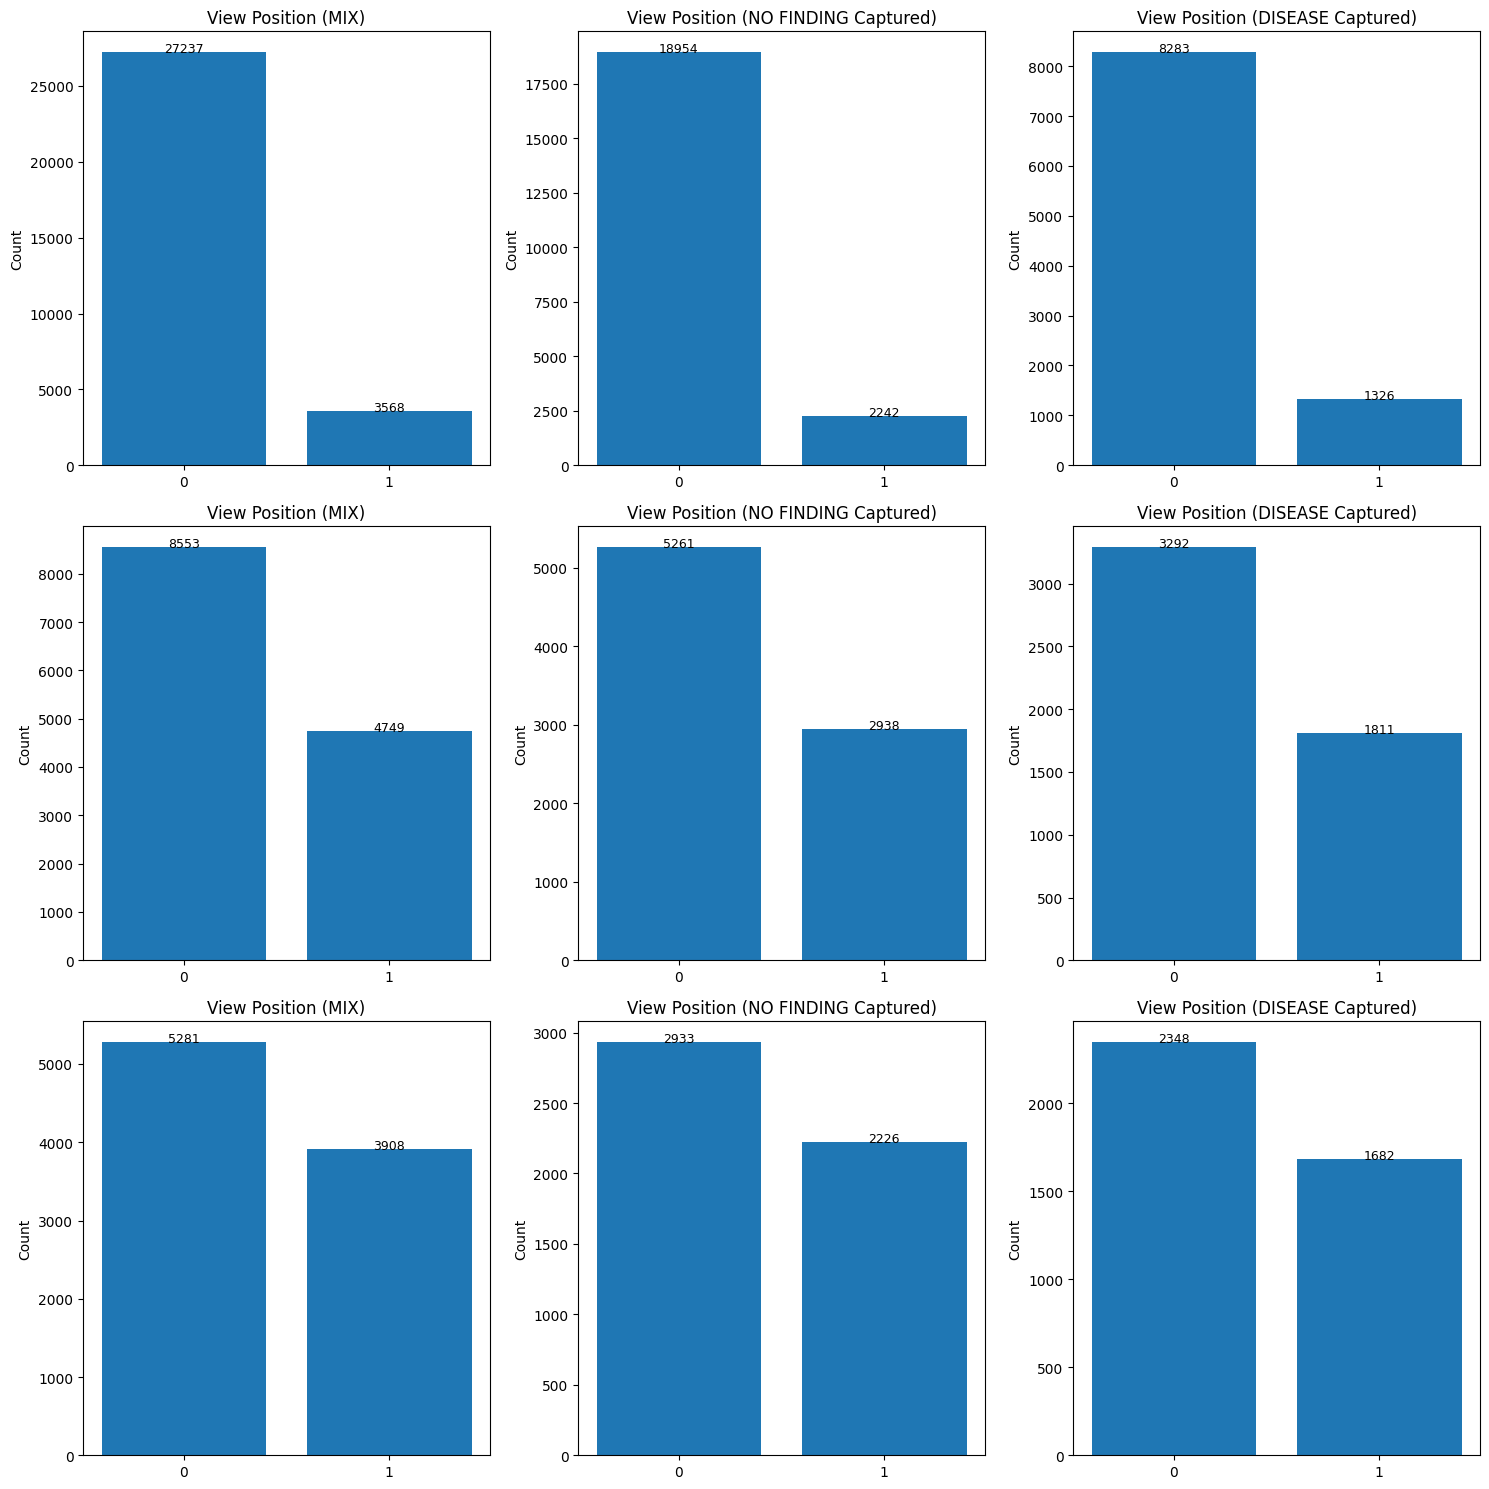

In [88]:
Show_Counts(all_data,df,all_titels)

In [ ]:
DATA_PATH = r"D:\Data"
ALL_IMGS_FOLDERS = [x for x in os.listdir(DATA_PATH) if x.startswith("images_")]

In [ ]:
ALL_IMGS_FOLDERS

['images_001',
 'images_002',
 'images_003',
 'images_004',
 'images_005',
 'images_006',
 'images_007',
 'images_008',
 'images_009',
 'images_010',
 'images_011',
 'images_012']